# Processing time courses.

In [1]:
from pathlib import Path
import numpy as np
current_dir = Path().resolve()
from microlive.imports import *
from microlive import microscopy as mi
from pipeline_time_courses import (
    compute_autocorrelation_for_dataset,
    compute_cross_correlation_for_dataset,
    analyze_crosscorr,
    analyze_dual_channel_time_courses,
    run_simulation_and_generate_data,
    plot_dual_channel_kymograph,
)

In [2]:
data_folder = Path('/Users/nzlab-la/Desktop/processing_GFPsf')
#data_folder = Path('/Users/nzlab-la/Desktop/processing_GFPuv')
#data_folder = Path('/Users/nzlab-la/Desktop/processing_GFP1X')
results_folder = data_folder.joinpath('processing')
results_folder.mkdir(exist_ok=True) 


plot_name = data_folder.name + '_ACF.svg'
plot_name

'processing_GFPsf_ACF.svg'

In [3]:
# Parameters
step_size_in_sec = 5
start_lag = 1
selected_field = 'spot_int_ch_' #'spot_int_ch_' #'spot_int_ch_'  # spot_int_ch_0, psf_amplitude_ch_, snr_ch_, total_spot_int_ch_
min_percentage_data_in_trajectory = 0.25
max_missing_frames = 3
downsample = False
downsampling_factor = 3
control_spots_mode = False
use_global_mean = False
dataset_name = 'cof'
y_axes_min_max_list_values =  [-0.02, 0.04]
x_axes_min_max_list_values = [-10, 1000]
max_lag = 250
if control_spots_mode:
    y_axes_min_max_list_values = None # [-20, 20]
remove_outliers = True
MAD_THRESHOLD_FACTOR = 6 # 6 was working well for the control spots. 
multi_tau=True
multi_tau_raw_points = 40
multi_tau_bins_per_stage = 20
min_snr = 0.5 # 1 #0.5
smooth_window = 1
correct_baseline = True
color_green = (0.0, 1.0, 0.0)  # No Red, Full Green, No Blue
color_magenta = (1.0, 0.0, 1.0)  # Full Red, No Green, Full Blue


line_color = (1.0, 0.0, 1.0)  # Full Red, No Green, Full Blue
line_color_fit = 'dimgray' # No Red, Full Green, No Blue

In [ ]:
# simulation mode
simulation_mode = False
# Load the sequences.
if simulation_mode:
    #gene_sequence_path = current_dir.parents[1].joinpath('data','gene_sequences','pRS032 (pUB-RBsmHA-4xmGFPuvq-2xmCherryq-24xMS2).dna')
    gene_sequence_path = current_dir.parents[1].joinpath('data','gene_sequences','pRS027 (pUB-RBsmHA-4xsfGFPq-2xmCherryq-24xMS2).dna')
    SSA_HA, SSA_GFP = run_simulation_and_generate_data(gene_sequence_path, ki=0.08, ke_global=6, step_size_in_sec=step_size_in_sec, folding_delay=7, t_max = 360*5,)
else:
    SSA_HA, SSA_GFP = None, None

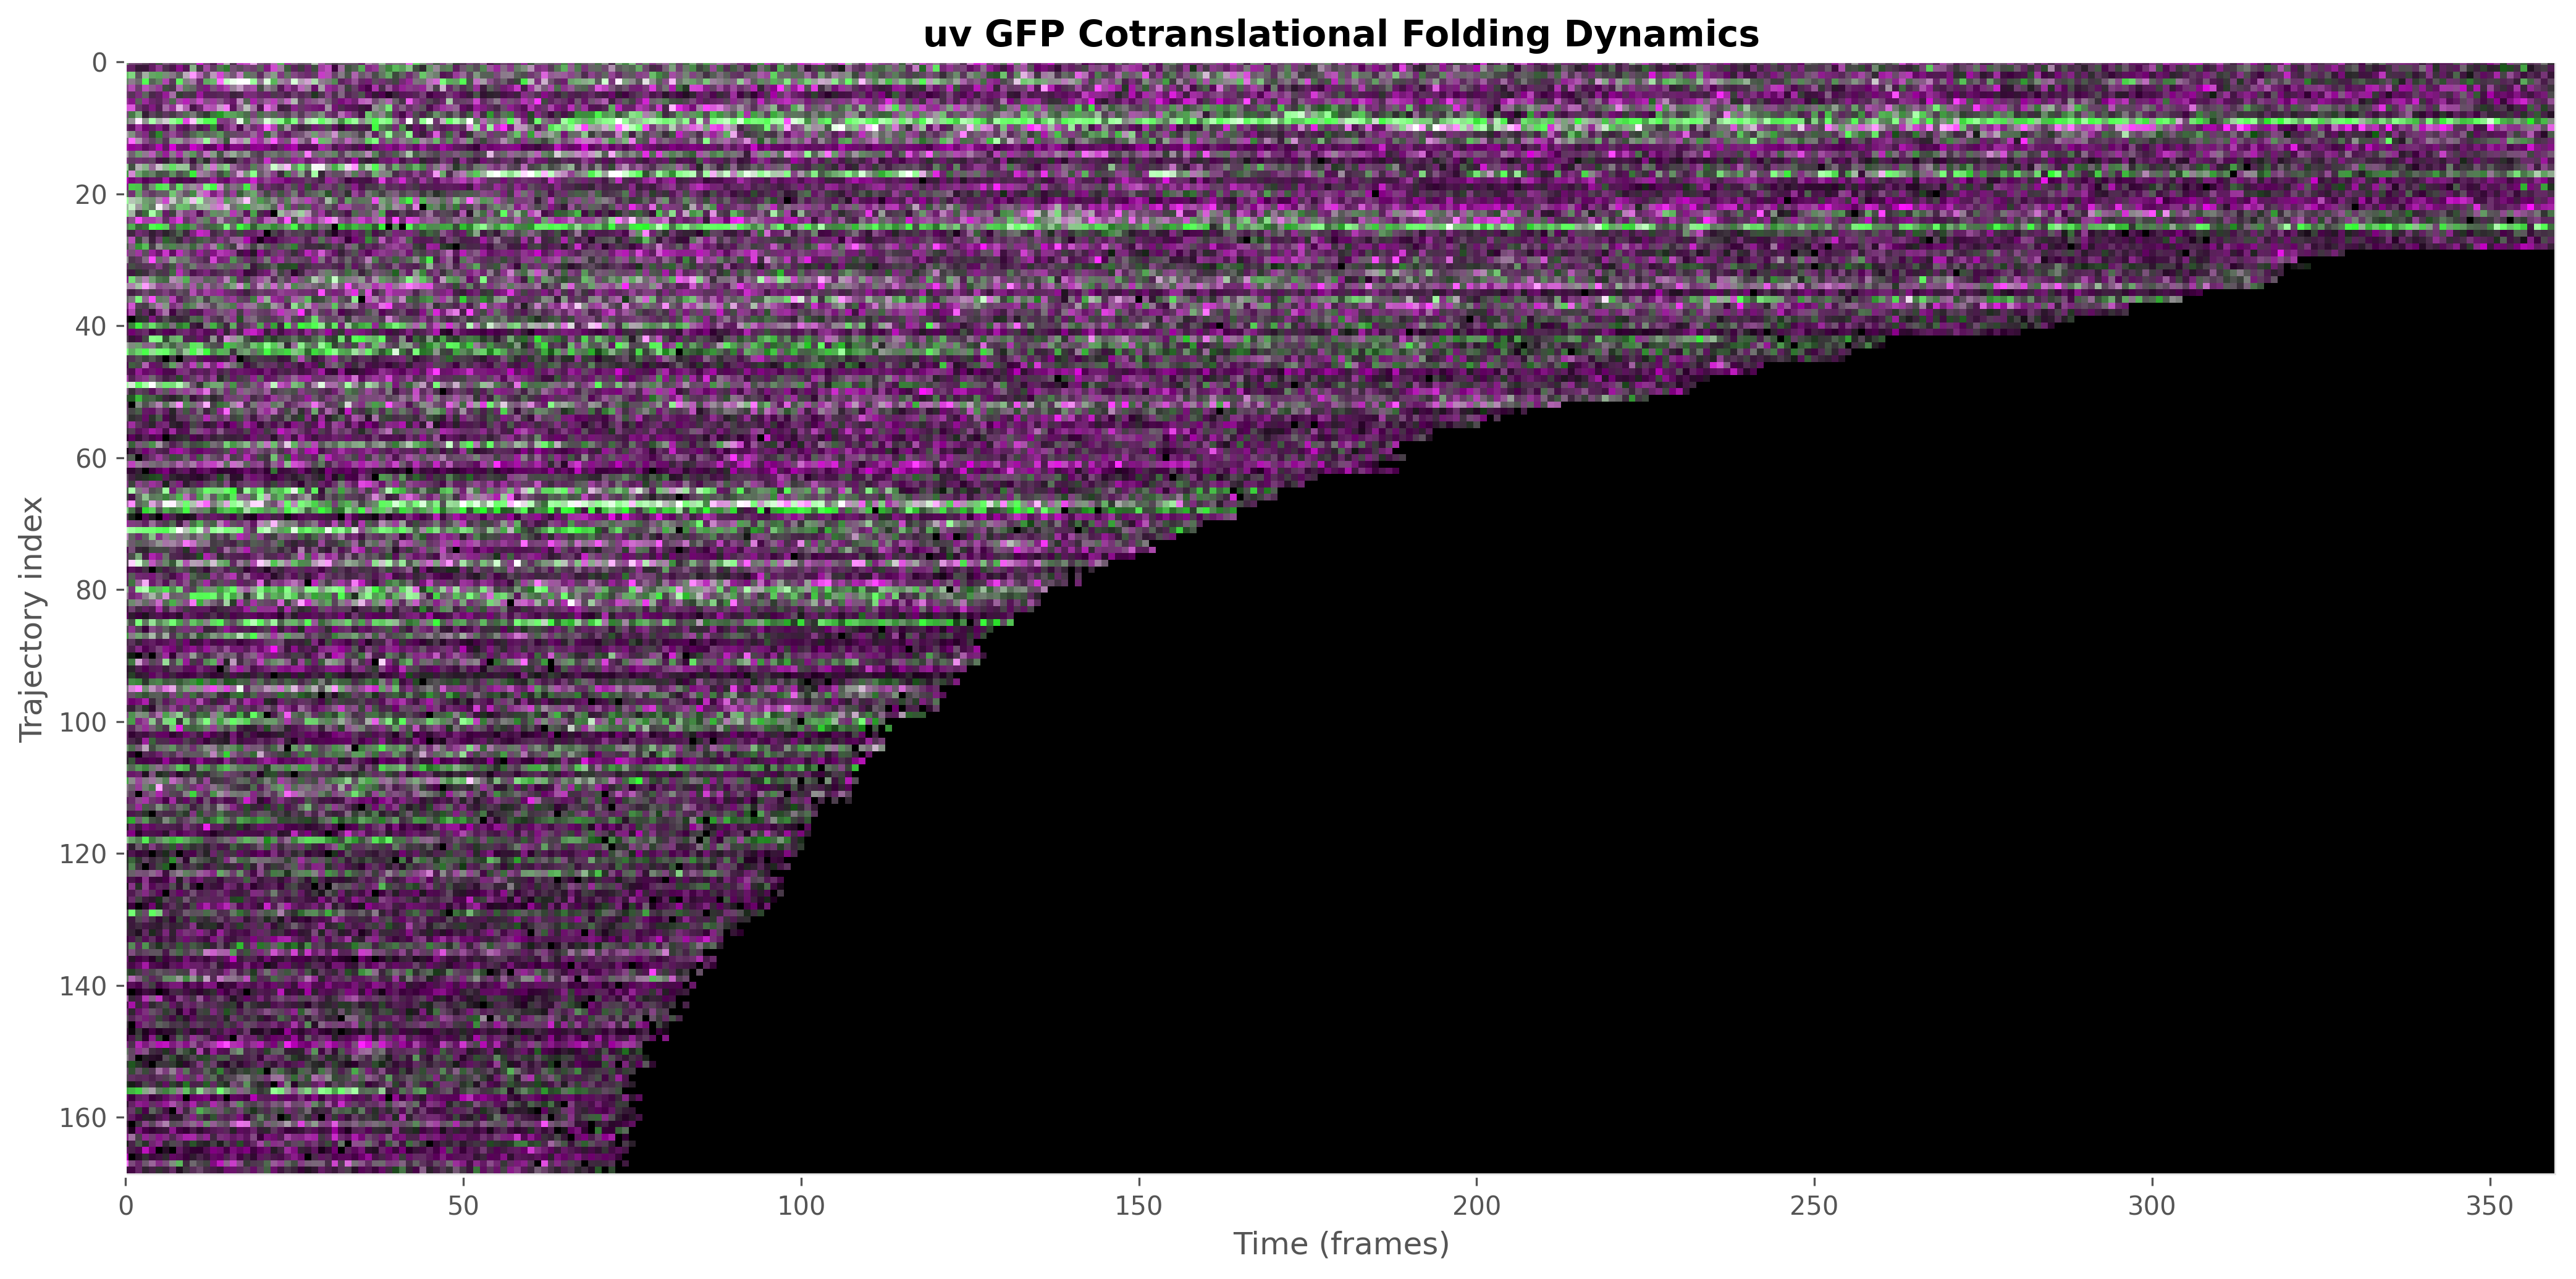

In [5]:
if simulation_mode:
    img, primary, secondary = plot_dual_channel_kymograph(
        dataset='cof',
        selected_field='snr_ch_',
        primary_channel=1,
        secondary_channel=0,
        normalize="per_trace_percentile",
        p_lo=1,
        p_hi=99,
        sort_by_data_density=True,
        nan_color=(0.0, 0.0, 0.0),  # Black for missing data
        title="Simulated Cotranslational Folding Dynamics",
        figsize=(12, 12),
        dpi=300,
        #save_path=results_folder / 'kymograph_simulation.png',
        show=True,
        verbose=False,
        simulation_mode=True,
        SSA_data_1=SSA_HA/np.max(SSA_HA),
        SSA_data_2=SSA_GFP/np.max(SSA_GFP),
        shift_data= True,
        use_binarization=True, 
        binarization_threshold=0.5,  
        channel_colors=['r', 'g'],
        #channel_colors=[(0.0, 1.0, 0.5), (1.0, 0.5, 0.0)],  # Custom blend
    )
else:
    img_exp, primary_exp, secondary_exp = plot_dual_channel_kymograph(
    dataset='cof',
    data_folder=data_folder,
    results_folder=results_folder,
    selected_field='snr_ch_',
    primary_channel=1,
    secondary_channel=0,
    min_percentage_data_in_trajectory=0.2,
    max_missing_frames=3,
    min_snr=0,
    smooth_window=1,
    normalize= None, #"per_trace_percentile", #"per_trace_percentile",
    p_lo=1,
    p_hi=99,
    sort_by_data_density=True,
    nan_color=(0.0, 0.0, 0.0),
    title="uv GFP Cotranslational Folding Dynamics",
    figsize=(14, 7),
    dpi=300,
    #channel_colors=['r', 'g'],
    channel_colors=[color_magenta, color_green,],  # Custom blend
    #save_path=results_folder / 'kymograph_experimental.png',
    show=True,
    verbose=False,
    simulation_mode=False,
    shift_data= True,
    use_binarization=False, 
    binarization_threshold=0.3,  
    max_traces_to_plot=190,
)

Fitted G(0): 0.03585651233852331


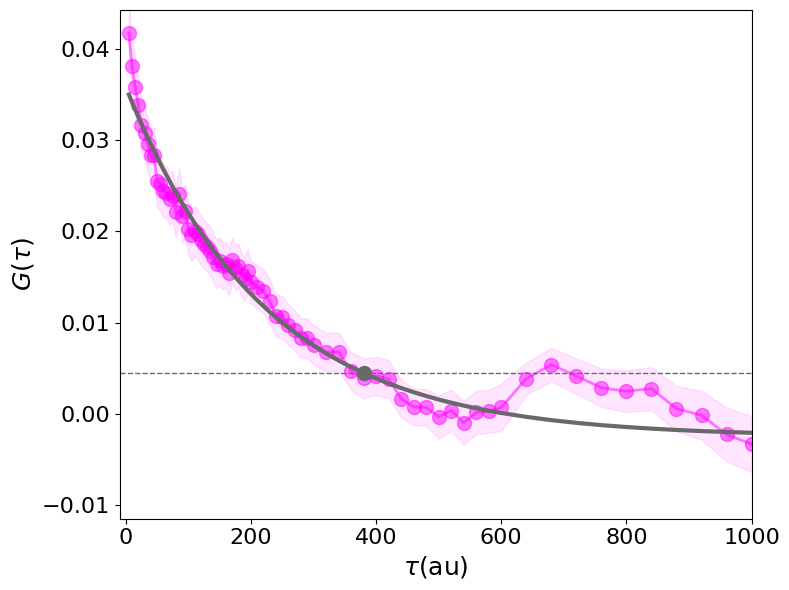

Number of trajectories: 120
Number of cells: 22


In [6]:
results = compute_autocorrelation_for_dataset(
    dataset=dataset_name,
    data_folder=data_folder,
    results_folder=results_folder,
    selected_field=selected_field,
    channel_index=1,
    step_size_in_sec=step_size_in_sec,
    start_lag=start_lag,
    min_percentage_data_in_trajectory=min_percentage_data_in_trajectory,
    max_missing_frames=max_missing_frames,
    downsample=downsample,
    downsampling_factor=downsampling_factor,
    use_global_mean=use_global_mean,
    control_spots_mode=control_spots_mode,
    correct_baseline=correct_baseline,  # correct_baseline,
    min_snr=min_snr,
    smooth_window=smooth_window,
    remove_outliers=remove_outliers,  # remove_outliers,
    MAD_THRESHOLD_FACTOR=MAD_THRESHOLD_FACTOR,
    multi_tau=multi_tau,
    multi_tau_raw_points=multi_tau_raw_points,
    multi_tau_bins_per_stage=multi_tau_bins_per_stage,
    x_axes_min_max_list_values=x_axes_min_max_list_values,
    max_lag = max_lag,
    index_max_lag_for_fit = None,
    fit_type='exponential',
    de_correlation_threshold=0.005,
    use_linear_projection_for_lag_0 = True,
    verbose=False,
    simulation_mode=simulation_mode,
    SSA_data=SSA_HA,
    baseline_method = 'auto_plateau',     # 'auto_plateau' | 'exp_tail' | 'percentile' | 'none'
    baseline_plateau_fraction = 0.5,   # fallback: last fraction of positive lags
    baseline_percentile = 30.0,         # fallback percentile (for 'percentile' and last-tail guards)
    baseline_smooth_window = 5,           # odd number
    baseline_min_points = 20,
    baseline_weight_by_pairs = True,
    line_color=line_color,
    line_color_fit=line_color_fit,
    plot_name= plot_name,
    save_plots= True,
    figsize=(3.2,2.2),
)

In [10]:
dwell_time = results['dwell_time']
correlation_at_lag_1 = results['mean_correlation'][1]

gene_length = 1826

ke = gene_length / dwell_time
ki = 1/ (correlation_at_lag_1* dwell_time)


In [11]:
# ribosomal density calculation
def calculate_ribosomal_density(ki, ke, ribosomal_footprint=10):
    ribosomal_density= (ki * ribosomal_footprint) / ke
    ribosomal_density = ribosomal_density * 100
    return np.round(ribosomal_density, 3)

def calculate_number_ribosomes_RNA(ki, ke, gene_length):
    number_ribosomes = (ki * gene_length) / ke
    return np.round(number_ribosomes, 3)

def calculate_ribosomal_distance(gene_length, number_ribosomes):
    ribosomal_distance = gene_length / number_ribosomes
    return np.round(ribosomal_distance, 3)

ribosomal_density = calculate_ribosomal_density(ki, ke)
number_ribosomes = calculate_number_ribosomes_RNA(ki, ke, gene_length)
ribosomal_distance = calculate_ribosomal_distance(gene_length, number_ribosomes)

ki_rounded = np.round(ki, 4)
ke_rounded = np.round(ke, 4)

print(f"Data: {data_folder.stem.replace('processing_', ''):<15} ki: {ki_rounded:<8} ke: {ke_rounded:<8} length: {gene_length:<5} rib_density: {ribosomal_density:<8} no_rib: {number_ribosomes:<8} rib_dist: {ribosomal_distance:<8}" )

Data: GFPsf           ki: 0.063    ke: 4.8053   length: 1826  rib_density: 13.119   no_rib: 23.955   rib_dist: 76.226  


In [12]:
raise SystemExit

SystemExit: 

Decorrelation threshold value: 0.00011320020138524922


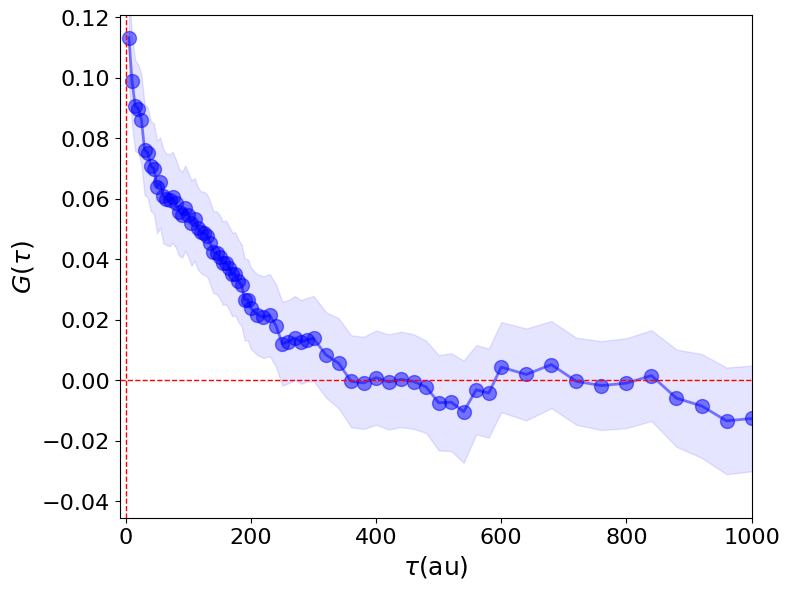

Number of trajectories: 89
Number of cells: 20


In [13]:
results = compute_autocorrelation_for_dataset(
    dataset=dataset_name,  
    data_folder=data_folder,
    results_folder=results_folder,
    selected_field=selected_field,
    channel_index=0,
    step_size_in_sec=step_size_in_sec,
    start_lag=start_lag,
    min_percentage_data_in_trajectory=min_percentage_data_in_trajectory,
    max_missing_frames=max_missing_frames,
    downsample=downsample,
    downsampling_factor=downsampling_factor,
    control_spots_mode=control_spots_mode,
    correct_baseline =correct_baseline,
    min_snr=min_snr,
    smooth_window=smooth_window,
    remove_outliers=remove_outliers,
    MAD_THRESHOLD_FACTOR=MAD_THRESHOLD_FACTOR,
    use_global_mean =use_global_mean,
    multi_tau=multi_tau,
    multi_tau_raw_points=multi_tau_raw_points,
    multi_tau_bins_per_stage=multi_tau_bins_per_stage,
    #y_axes_min_max_list_values=y_axes_min_max_list_values,
    x_axes_min_max_list_values=x_axes_min_max_list_values,
    max_lag = max_lag,
    index_max_lag_for_fit = 40,
    verbose=False,
    simulation_mode=simulation_mode,
    SSA_data=SSA_GFP,
)

## Compute cross-correlation


    ERROR: No trajectories passed dual-channel quality filter
    ERROR: No trajectories passed dual-channel quality filter
    ERROR: No trajectories passed dual-channel quality filter
Final synchronized trajectories: 137
Number of cells: 19
Flat plateau detected: 4 points, using center at lag 5.0 s
Plateau tolerance: 2.0%, corresponds to 0.001 units below peak value 0.032
Plateau lag range: -5.0 s to 10.0 s


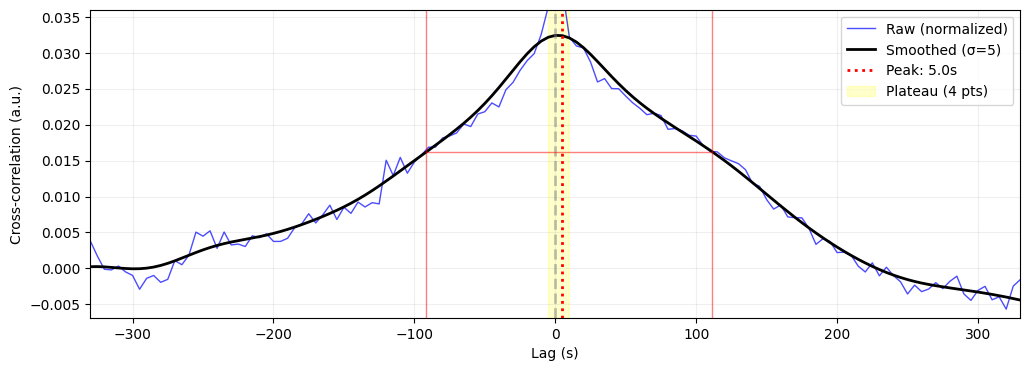

In [14]:
selected_field_ccf = 'spot_int_ch_' #'spot_int_ch_' #'spot_int_ch_'  # spot_int_ch_0, psf_amplitude_ch_, snr_ch_, total_spot_int_ch_
smooth_window_cff = 1
min_percentage_data_in_trajectory_ccf = 0.2
min_snr_ccf = 1
nan_handling_ccf = 'ignore'
max_missing_frames_ccf = 3
MAD_THRESHOLD_FACTOR_ccf = 6

results = compute_cross_correlation_for_dataset(
    dataset=dataset_name,
    data_folder=data_folder,
    results_folder=results_folder,
    selected_field=selected_field_ccf,
    primary_channel=1,    # HA_TAG (appears first)
    secondary_channel=0,  # GFP_TAG (appears second - delayed)
    control_spots_mode=control_spots_mode,
    step_size_in_sec=step_size_in_sec,
    start_lag=start_lag,
    min_percentage_data_in_trajectory=min_percentage_data_in_trajectory_ccf,
    max_missing_frames=max_missing_frames_ccf,
    min_snr=min_snr_ccf,
    smooth_window=smooth_window_cff,
    MAD_THRESHOLD_FACTOR=MAD_THRESHOLD_FACTOR_ccf,
    x_axes_min_max_list_values=x_axes_min_max_list_values,
    correct_baseline=False,
    use_linear_projection_for_lag_0=False,
    use_global_mean=False,
    remove_outliers=True,
    return_full=True,
    verbose=False,
    show_plot=False,
    shift_data=False,
    nan_handling=nan_handling_ccf,
    simulation_mode=simulation_mode,
    SSA_data_1=SSA_HA,
    SSA_data_2=SSA_GFP,
)

max_lag_selected = 300
metrics, corr_interp, lags_s = analyze_crosscorr(
    results['mean_correlation'], 
    dt=step_size_in_sec, 
    plot=True, 
    window_s=max_lag_selected, 
    slope_window_pts=3, 
    halfmax_fraction=0.5, 
    plateau_tolerance=0.02,
    sigma_smooth=5,  # Add smoothing parameter
    min_max_normalize=False,  # Add normalization parameter
    figsize =(12, 4),
)

## Processing time courses
___

    ERROR: No trajectories passed dual-channel quality filter


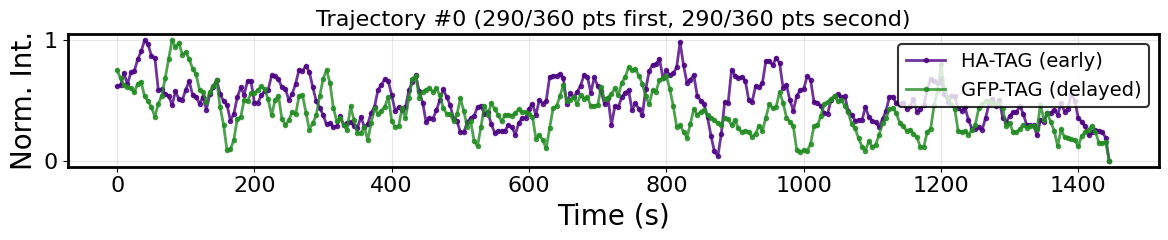

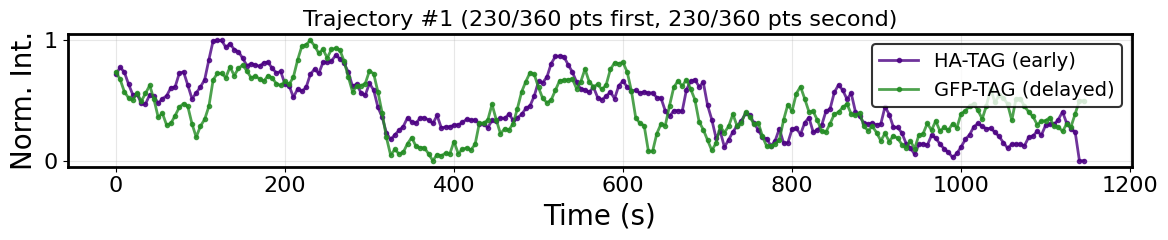

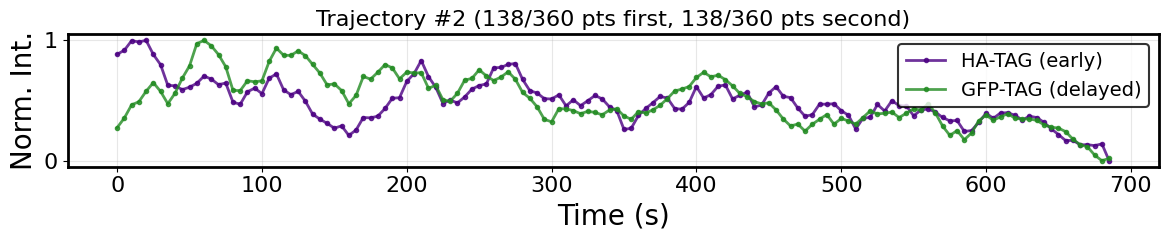

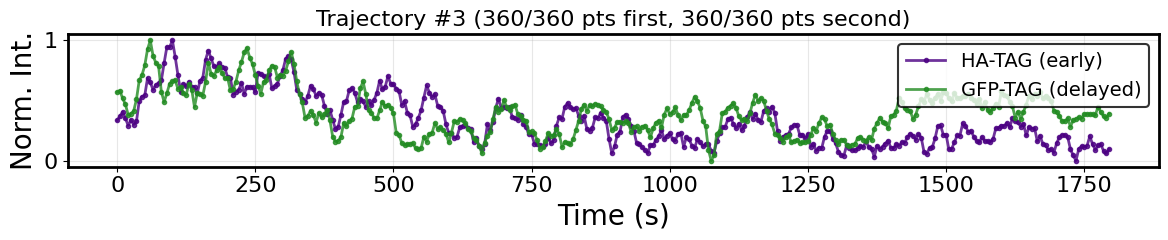

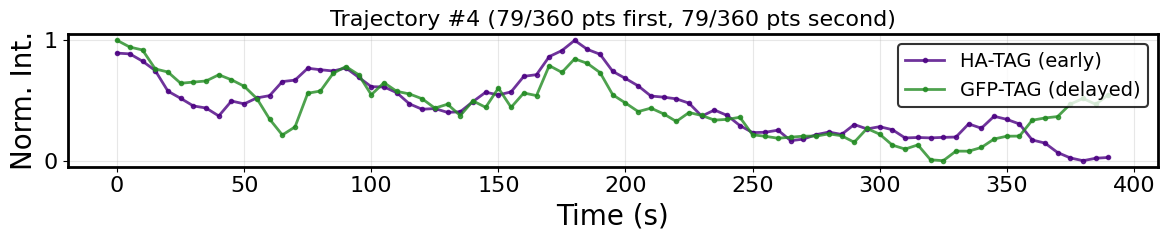

Number of accepted minima: 104


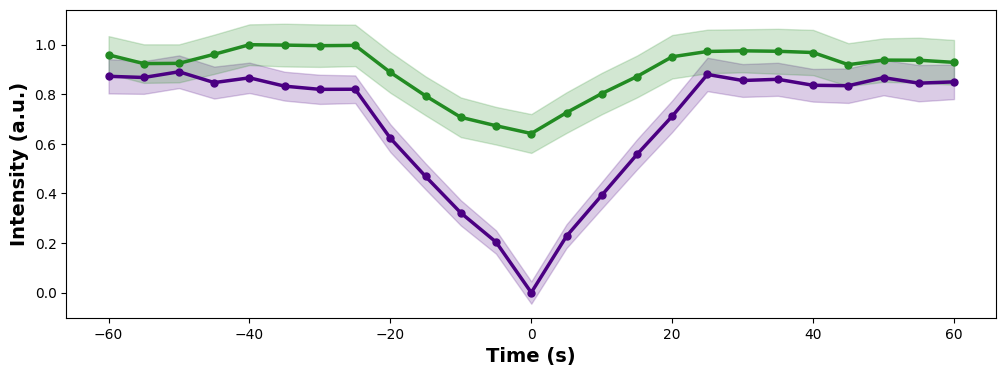

In [15]:
results = analyze_dual_channel_time_courses(
    dataset='cof',
    data_folder=data_folder,
    results_folder=results_folder,
    selected_field='spot_int_ch_',
    primary_channel=1,
    secondary_channel=0,
    step_size_in_sec=5,
    min_snr=0.5,
    # Time courses
    show_time_courses=5,
    trajectory_smooth_window=5,
    #trajectory_colors=['forestgreen', 'indigo'],
    trajectory_colors=['indigo', 'forestgreen'],
    trajectory_labels=['HA-TAG (early)', 'GFP-TAG (delayed)'],
    trajectory_figsize=(12, 2.5),
    normalize_trajectories=True,
    # Minima analysis
    show_minima_analysis=True,
    minima_threshold=0.35,
    minima_window=12,
    #normalization='min_max',
    normalization='min_max',
    #normalization='per_trace_percentile',
    #percentile =99,
    n_random=1000,
    n_boot=500,
    minima_smooth_window=5,
    # Minima plot
    primary_label="HA",
    secondary_label="GFP",
    #minima_plot_title="Cotranslational Folding Dynamics",
    minima_figsize=(12, 4),
    show_fits=False,
    # General
    save_results=False,
    verbose=False,
    minima_normalization_mode='shared', # 'shared', 'independent', or 'none'
    simulation_mode=simulation_mode,
    SSA_data_1=SSA_HA,
    SSA_data_2=SSA_GFP,
    show_delay= False,
    detect_maxima= False,
)